# Basel III Liquidity Risk Calculator
## LCR & NSFR | Delegated Regulation (EU) 2022/786 / CRR Art. 428a–428at

**Institution:** Major European G-SIB (anonymised)  
**Reference year:** 2025A | Forecast: 2026F–2028F  
**Scenarios:** Base | Rate Hike | Rate Cut | Stress  
**Author:** Hossam Eltarrass

---

### What this notebook calculates

**LCR (Liquidity Coverage Ratio)** — Del. Reg. (EU) 2022/786  
Measures whether the bank holds enough High Quality Liquid Assets (HQLA)
to survive 30 days of stressed net cash outflows.

$$\text{LCR} = \frac{\text{HQLA}}{\text{Net Cash Outflows (30d)}} \geq 100\%$$

**NSFR (Net Stable Funding Ratio)** — CRR Art. 428a–428at  
Measures whether the bank's funding structure is stable enough relative
to its asset profile over a 1-year horizon.

$$\text{NSFR} = \frac{\text{Available Stable Funding (ASF)}}{\text{Required Stable Funding (RSF)}} \geq 100\%$$

Both ratios are computed under 4 macro scenarios.
Results are cross-checked against the Excel master model.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd          # tables and DataFrames
import numpy as np           # numerical calculations
import matplotlib.pyplot as plt  # charts
import matplotlib.ticker as mticker  # number formatting on chart axes

# Display settings — makes tables print cleanly in the notebook
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
pd.set_option("display.max_columns", 20)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
## ── Balance Sheet 2025A (EUR millions) ───────────────────────────────────────
# Source: Master Balance Sheet sheet — same figures as Project 1 & 2

# Assets
cash_cb        = 211_330   # Cash & CB reserves — Level 1 HQLA
loans          = 897_358   # Loans to customers
ib_loans       = 26_259    # Interbank loans
securities     = 153_107   # Securities portfolio (72% govt, 28% corp bonds)
insurance      = 305_471   # Insurance investment assets (100% RSF — CRR Art.428ab)
trading        = 870_245   # Trading assets (40% sovereign, 30% deriv, 30% other)

# Liabilities
deposits       = 1_075_564 # Customer deposits
ib_funding     = 69_938    # Interbank funding (financial institution)
repo           = 357_947   # Repo funding (72% Level 1, 28% Level 2A collateral)
bonds_issued   = 173_933   # Bonds issued (>1Y maturity assumed)
sub_debt       = 34_468    # Subordinated debt
cb_deposits    = 4_401     # Deposits from central banks

# Equity
equity         = 132_173   # Total equity (CET1 + AT1 + T2 — 100% ASF)

# Securities split (from Engine sheet Section A4)
gov_bond_pct   = 0.72
corp_bond_pct  = 0.28
gov_bonds      = securities * gov_bond_pct   # = €110,237m — Level 1
corp_bonds     = securities * corp_bond_pct  # = €42,870m  — Level 2A

print(f"Government bonds (Level 1):  €{gov_bonds:>10,.1f}m")
print(f"Corporate bonds  (Level 2A): €{corp_bonds:>10,.1f}m")
print(f"Securities total check:      €{gov_bonds + corp_bonds:>10,.1f}m  (should = {securities:,})")

# ── Scenario Definitions ─────────────────────────────────────────────────────
scenarios = {
    "Base":      {"dep_growth": 0.025, "loan_growth": 0.030, "stable_pct": 0.70},
    "Rate Hike": {"dep_growth": 0.020, "loan_growth": 0.020, "stable_pct": 0.65},
    "Rate Cut":  {"dep_growth": 0.030, "loan_growth": 0.040, "stable_pct": 0.72},
    "Stress":    {"dep_growth": 0.000, "loan_growth": 0.010, "stable_pct": 0.50},
}

print("\nScenarios defined:")
for name, params in scenarios.items():
    print(f"  {name:<12} | deposit growth: {params['dep_growth']*100:.1f}%"
          f"  | loan growth: {params['loan_growth']*100:.1f}%"
          f"  | stable deposits: {params['stable_pct']*100:.0f}%")

Government bonds (Level 1):  € 110,237.0m
Corporate bonds  (Level 2A): €  42,870.0m
Securities total check:      € 153,107.0m  (should = 153,107)

Scenarios defined:
  Base         | deposit growth: 2.5%  | loan growth: 3.0%  | stable deposits: 70%
  Rate Hike    | deposit growth: 2.0%  | loan growth: 2.0%  | stable deposits: 65%
  Rate Cut     | deposit growth: 3.0%  | loan growth: 4.0%  | stable deposits: 72%
  Stress       | deposit growth: 0.0%  | loan growth: 1.0%  | stable deposits: 50%


In [3]:
# ── LCR Parameters | Delegated Regulation (EU) 2022/786 ──────────────────────

lcr_params = {

    # HQLA haircuts
    "haircut_l1":        0.00,   # Art.10(1)(a)(d-g): Level 1 — 0% haircut
    "haircut_l2a":       0.15,   # Art.11(1)(b): Level 2A — 15% haircut

    # Outflow rates
    "out_retail_stable": 0.05,   # Art.24: retail stable deposits — 5%
    "out_retail_less":   0.10,   # Art.25: retail less stable deposits — 10%
    "out_wholesale":     0.25,   # Art.27(3): wholesale non-operational — 25%
    "out_fin_inst":      1.00,   # Art.31: financial institution unsecured — 100%
    "out_repo_l1":       0.00,   # Art.28(3)(a): repo secured by Level 1 — 0%
    "out_repo_l2a":      0.15,   # Art.28(3)(b): repo secured by Level 2A — 15%
    "out_cb_excess":     0.25,   # Art.27: CB excess reserve drawdown — 25%
    "out_commitments":   0.10,   # Art.32: undrawn committed facilities — 10%

    # Repo collateral split
    "repo_l1_pct":       0.72,   # 72% of repo backed by Level 1
    "repo_l2a_pct":      0.28,   # 28% of repo backed by Level 2A

    # CB excess reserves assumption
    "cb_excess_pct":     0.15,   # 15% of CB reserves treated as excess

    # Inflow rates
    "in_loans":          0.50,   # Art.32(3)(a): performing loans maturing ≤30d — 50%
    "in_securities":     1.00,   # Art.32(3)(c): securities maturing ≤30d — 100%

    # Maturity assumptions
    "loan_mature_pct":   0.10,   # 10% of loans mature within 30 days
    "sec_mature_pct":    0.109,  # ~10.9% of securities mature within 30 days

    # Inflow cap
    "inflow_cap":        0.75,   # Art.33: mandatory 75% cap
}

print("LCR parameters loaded ✓")
print(f"\nKey rates:")
print(f"  Level 1 haircut:          {lcr_params['haircut_l1']*100:.0f}%  (Art.10)")
print(f"  Level 2A haircut:         {lcr_params['haircut_l2a']*100:.0f}%  (Art.11)")
print(f"  Retail stable outflow:    {lcr_params['out_retail_stable']*100:.0f}%  (Art.24)")
print(f"  Retail less stable:       {lcr_params['out_retail_less']*100:.0f}% (Art.25)")
print(f"  Financial inst. outflow:  {lcr_params['out_fin_inst']*100:.0f}% (Art.31)")
print(f"  Inflow cap:               {lcr_params['inflow_cap']*100:.0f}% (Art.33)")

LCR parameters loaded ✓

Key rates:
  Level 1 haircut:          0%  (Art.10)
  Level 2A haircut:         15%  (Art.11)
  Retail stable outflow:    5%  (Art.24)
  Retail less stable:       10% (Art.25)
  Financial inst. outflow:  100% (Art.31)
  Inflow cap:               75% (Art.33)


In [4]:
# ── LCR Calculation Engine | Del. Reg. (EU) 2022/786 ─────────────────────────

def calculate_lcr(scenario_name, dep_vol, loan_vol, stable_pct):
    """
    Calculate LCR for one scenario.

    Parameters
    ----------
    scenario_name : str   — label for this scenario
    dep_vol       : float — customer deposit volume (scenario-adjusted, €m)
    loan_vol      : float — loan volume (scenario-adjusted, €m)
    stable_pct    : float — share of deposits classified as stable (NMD model)
    """
    p = lcr_params

    # ── STEP 1: HQLA Stock ───────────────────────────────────────────────────
    hqla_l1_cash  = cash_cb
    hqla_l1_bonds = gov_bonds
    hqla_l2a      = corp_bonds   # Face value — consistent with Excel model

    total_hqla = hqla_l1_cash + hqla_l1_bonds + hqla_l2a

    # ── STEP 2: 30-Day Outflows ──────────────────────────────────────────────
    # NMD split is now scenario-sensitive (fixes static 70/30 assumption)
    stable_deps   = dep_vol * stable_pct          # scenario-specific stable %
    less_stable   = dep_vol * (1 - stable_pct)    # remainder = less stable

    out_stable    = stable_deps  * p["out_retail_stable"]          # Art.24: 5%
    out_less      = less_stable  * p["out_retail_less"]            # Art.25: 10%
    out_wholesale = bonds_issued * p["out_wholesale"]              # Art.27(3): 25%
    out_fin_inst  = ib_funding   * p["out_fin_inst"]               # Art.31: 100%
    out_repo_l1   = repo * p["repo_l1_pct"] * p["out_repo_l1"]    # Art.28(3)(a): 0%
    out_repo_l2a  = repo * p["repo_l2a_pct"] * p["out_repo_l2a"]  # Art.28(3)(b): 15%
    out_cb        = cash_cb * p["cb_excess_pct"] * p["out_cb_excess"]  # Art.27: 25%
    out_commit    = loan_vol * p["out_commitments"]                # Art.32: 10%

    total_outflows = (out_stable + out_less + out_wholesale + out_fin_inst +
                      out_repo_l1 + out_repo_l2a + out_cb + out_commit)

    # ── STEP 3: 30-Day Inflows ───────────────────────────────────────────────
    in_loans = (loan_vol   * p["loan_mature_pct"]) * p["in_loans"]
    in_secs  = (securities * p["sec_mature_pct"])  * p["in_securities"]

    total_inflows = in_loans + in_secs

    # ── STEP 4: Apply the 75% inflow cap (Art.33) ───────────────────────────
    capped_inflows = min(total_inflows, total_outflows * p["inflow_cap"])

    # ── STEP 5: Net Outflows and LCR Ratio ───────────────────────────────────
    net_outflows = total_outflows - capped_inflows
    lcr_ratio    = total_hqla / net_outflows

    return {
        "Scenario":               scenario_name,
        "Stable dep % (NMD)":     f"{stable_pct*100:.0f}%",
        "L1 Cash & CB (€m)":      hqla_l1_cash,
        "L1 Govt Bonds (€m)":     hqla_l1_bonds,
        "L2A Corp Bonds (€m)":    hqla_l2a,
        "Total HQLA (€m)":        total_hqla,
        "Out: Stable deps (€m)":  out_stable,
        "Out: Less stable (€m)":  out_less,
        "Out: Wholesale (€m)":    out_wholesale,
        "Out: Fin inst (€m)":     out_fin_inst,
        "Out: Repo L2A (€m)":     out_repo_l2a,
        "Out: CB excess (€m)":    out_cb,
        "Out: Commitments (€m)":  out_commit,
        "Total Outflows (€m)":    total_outflows,
        "In: Loans (€m)":         in_loans,
        "In: Securities (€m)":    in_secs,
        "Total Inflows (€m)":     total_inflows,
        "Capped Inflows (€m)":    capped_inflows,
        "Net Outflows (€m)":      net_outflows,
        "LCR Ratio":              lcr_ratio,
        "LCR (%)":                lcr_ratio * 100,
        "Passes (≥100%)?":        "✅ PASS" if lcr_ratio >= 1.0 else "❌ BREACH",
    }

# ── Run all 4 scenarios ───────────────────────────────────────────────────────
lcr_results = []

for name, params in scenarios.items():
    dep_vol    = deposits * (1 + params["dep_growth"])
    loan_vol   = loans    * (1 + params["loan_growth"])
    stable_pct = params["stable_pct"]   # ← now passed from scenario definition

    result = calculate_lcr(name, dep_vol, loan_vol, stable_pct)
    lcr_results.append(result)

lcr_df = pd.DataFrame(lcr_results).set_index("Scenario")

summary_rows = ["Stable dep % (NMD)", "Total HQLA (€m)", "Total Outflows (€m)",
                "Capped Inflows (€m)", "Net Outflows (€m)",
                "LCR (%)", "Passes (≥100%)?"]

print("=" * 60)
print("LCR RESULTS — All Scenarios (with NMD model)")
print("=" * 60)
print(lcr_df.loc[:, summary_rows].T.to_string())

LCR RESULTS — All Scenarios (with NMD model)
Scenario                 Base Rate Hike  Rate Cut    Stress
Stable dep % (NMD)        70%       65%       72%       50%
Total HQLA (€m)     364,437.0 364,437.0 364,437.0 364,437.0
Total Outflows (€m) 300,467.2 301,963.0 300,606.3 307,680.4
Capped Inflows (€m)  62,902.6  62,453.9  63,351.3  62,005.2
Net Outflows (€m)   237,564.6 239,509.1 237,255.0 245,675.1
LCR (%)                 153.4     152.2     153.6     148.3
Passes (≥100%)?        ✅ PASS    ✅ PASS    ✅ PASS    ✅ PASS


In [5]:
# ── NSFR Parameters | CRR Art. 428a–428at ────────────────────────────────────
# ASF = how stable is each funding source? (higher % = more stable)
# RSF = how much stable funding does each asset require? (higher % = more needed)

nsfr_params = {

    # ── ASF Factors (Available Stable Funding) ────────────────────────────────
    "asf_equity":          1.00,  # CRR Art.428d:    Equity — fully stable
    "asf_stable_dep":      0.90,  # CRR Art.428h:    Retail stable deposits — 90%
    "asf_less_stable_dep": 0.80,  # CRR Art.428i:    Retail less stable deposits — 80%
    "asf_bonds_gt1y":      1.00,  # CRR Art.428n:    Bonds issued >1Y maturity — 100%
    "asf_sub_debt":        0.50,  # CRR Art.428o:    Subordinated debt — 50%
    "asf_ib_lt6m":         0.00,  # CRR Art.428p:    Interbank funding <6M — 0%
    "asf_repo_l1":         0.10,  # CRR Art.428s:    Repo secured by Level 1 — 10%
    "asf_cb_deposits":     0.00,  # CRR Art.428p:    CB deposits — 0%

    # ── RSF Factors (Required Stable Funding) ─────────────────────────────────
    "rsf_cash":            0.00,  # CRR Art.428q:    Cash — 0% (most liquid)
    "rsf_l1_bonds":        0.05,  # CRR Art.428r:    Level 1 HQLA bonds — 5%
    "rsf_l2a_bonds":       0.15,  # CRR Art.428s:    Level 2A HQLA bonds — 15%
    "rsf_loans_gt1y":      0.85,  # CRR Art.428t:    Loans >1Y residual maturity — 85%
    "rsf_loans_lt1y":      0.50,  # CRR Art.428u:    Loans <1Y residual maturity — 50%
    "rsf_ib_loans":        0.10,  # CRR Art.428u:    Interbank loans short-term — 10%
    "rsf_insurance":       1.00,  # CRR Art.428ab:   Insurance assets — 100%

    # Trading asset RSF factors (refined split from Engine sheet)
    "rsf_trading_l1":      0.05,  # CRR Art.428r:    Trading — sovereign/Level 1
    "rsf_trading_deriv":   0.10,  # CRR Art.428ag:   Trading — derivatives & structured
    "rsf_trading_other":   0.85,  # CRR Art.428ab:   Trading — other assets

    # ── Loan maturity split (from Engine sheet) ───────────────────────────────
    "loan_gt1y_pct":       0.75,  # 75% of loans have >1Y residual maturity
    "loan_lt1y_pct":       0.25,  # 25% of loans have <1Y residual maturity

    # ── Trading asset composition (from Engine sheet) ─────────────────────────
    "trading_l1_pct":      0.40,  # 40% of trading = sovereign / Level 1
    "trading_deriv_pct":   0.30,  # 30% of trading = derivatives & structured
    "trading_other_pct":   0.30,  # 30% of trading = other trading assets
}

print("NSFR parameters loaded ✓")
print(f"\nKey ASF factors:")
print(f"  Equity:                {nsfr_params['asf_equity']*100:.0f}%  (Art.428d)")
print(f"  Retail stable deps:    {nsfr_params['asf_stable_dep']*100:.0f}%  (Art.428h)")
print(f"  Retail less stable:    {nsfr_params['asf_less_stable_dep']*100:.0f}%  (Art.428i)")
print(f"  Interbank <6M:          {nsfr_params['asf_ib_lt6m']*100:.0f}%  (Art.428p)")
print(f"\nKey RSF factors:")
print(f"  Cash:                   {nsfr_params['rsf_cash']*100:.0f}%  (Art.428q)")
print(f"  Level 1 bonds:          {nsfr_params['rsf_l1_bonds']*100:.0f}%  (Art.428r)")
print(f"  Loans >1Y:             {nsfr_params['rsf_loans_gt1y']*100:.0f}%  (Art.428t)")
print(f"  Insurance assets:      {nsfr_params['rsf_insurance']*100:.0f}% (Art.428ab)")

NSFR parameters loaded ✓

Key ASF factors:
  Equity:                100%  (Art.428d)
  Retail stable deps:    90%  (Art.428h)
  Retail less stable:    80%  (Art.428i)
  Interbank <6M:          0%  (Art.428p)

Key RSF factors:
  Cash:                   0%  (Art.428q)
  Level 1 bonds:          5%  (Art.428r)
  Loans >1Y:             85%  (Art.428t)
  Insurance assets:      100% (Art.428ab)


In [6]:
# ── NSFR Calculation Engine | CRR Art. 428a–428at ────────────────────────────

def calculate_nsfr(scenario_name, dep_vol, loan_vol, stable_pct):
    """
    Calculate NSFR for one scenario.

    Parameters
    ----------
    scenario_name : str   — label for this scenario
    dep_vol       : float — customer deposit volume (scenario-adjusted, €m)
    loan_vol      : float — loan volume (scenario-adjusted, €m)
    stable_pct    : float — share of deposits classified as stable (NMD model)
    """
    p = nsfr_params

    # ── STEP 1: Available Stable Funding (ASF) ───────────────────────────────
    stable_deps    = dep_vol * stable_pct            # scenario-sensitive NMD split
    less_stable    = dep_vol * (1 - stable_pct)      # remainder = less stable

    asf_equity     = equity       * p["asf_equity"]
    asf_stable     = stable_deps  * p["asf_stable_dep"]
    asf_less       = less_stable  * p["asf_less_stable_dep"]
    asf_bonds      = bonds_issued * p["asf_bonds_gt1y"]
    asf_sub        = sub_debt     * p["asf_sub_debt"]
    asf_ib         = ib_funding   * p["asf_ib_lt6m"]
    asf_repo       = repo         * p["asf_repo_l1"]
    asf_cb         = cb_deposits  * p["asf_cb_deposits"]

    total_asf = (asf_equity + asf_stable + asf_less + asf_bonds +
                 asf_sub + asf_ib + asf_repo + asf_cb)

    # ── STEP 2: Required Stable Funding (RSF) ───────────────────────────────
    rsf_loans = (loan_vol * p["loan_gt1y_pct"] * p["rsf_loans_gt1y"] +
                 loan_vol * p["loan_lt1y_pct"]  * p["rsf_loans_lt1y"])

    rsf_gov_bonds  = gov_bonds  * p["rsf_l1_bonds"]
    rsf_corp_bonds = corp_bonds * p["rsf_l2a_bonds"]
    rsf_cash       = cash_cb    * p["rsf_cash"]
    rsf_insurance  = insurance  * p["rsf_insurance"]
    rsf_ib_loans   = ib_loans   * p["rsf_ib_loans"]

    rsf_trading = (trading * p["trading_l1_pct"]    * p["rsf_trading_l1"]    +
                   trading * p["trading_deriv_pct"] * p["rsf_trading_deriv"] +
                   trading * p["trading_other_pct"] * p["rsf_trading_other"])

    total_rsf = (rsf_loans + rsf_gov_bonds + rsf_corp_bonds +
                 rsf_cash + rsf_insurance + rsf_ib_loans + rsf_trading)

    # ── STEP 3: NSFR Ratio ───────────────────────────────────────────────────
    nsfr_ratio = total_asf / total_rsf

    return {
        "Scenario":                  scenario_name,
        "Stable dep % (NMD)":        f"{stable_pct*100:.0f}%",
        "ASF: Equity (€m)":          asf_equity,
        "ASF: Stable deps (€m)":     asf_stable,
        "ASF: Less stable (€m)":     asf_less,
        "ASF: Bonds >1Y (€m)":       asf_bonds,
        "ASF: Sub debt (€m)":        asf_sub,
        "ASF: Interbank (€m)":       asf_ib,
        "ASF: Repo (€m)":            asf_repo,
        "Total ASF (€m)":            total_asf,
        "RSF: Loans (€m)":           rsf_loans,
        "RSF: Govt bonds (€m)":      rsf_gov_bonds,
        "RSF: Corp bonds (€m)":      rsf_corp_bonds,
        "RSF: Cash (€m)":            rsf_cash,
        "RSF: Insurance (€m)":       rsf_insurance,
        "RSF: IB loans (€m)":        rsf_ib_loans,
        "RSF: Trading (€m)":         rsf_trading,
        "Total RSF (€m)":            total_rsf,
        "NSFR Ratio":                nsfr_ratio,
        "NSFR (%)":                  nsfr_ratio * 100,
        "Passes (≥100%)?":           "✅ PASS" if nsfr_ratio >= 1.0 else "❌ BREACH",
    }

# ── Run all 4 scenarios ───────────────────────────────────────────────────────
nsfr_results = []

for name, params in scenarios.items():
    dep_vol    = deposits * (1 + params["dep_growth"])
    loan_vol   = loans    * (1 + params["loan_growth"])
    stable_pct = params["stable_pct"]

    result = calculate_nsfr(name, dep_vol, loan_vol, stable_pct)
    nsfr_results.append(result)

nsfr_df = pd.DataFrame(nsfr_results).set_index("Scenario")

summary_rows = ["Stable dep % (NMD)", "Total ASF (€m)", "Total RSF (€m)",
                "NSFR (%)", "Passes (≥100%)?"]

print("=" * 60)
print("NSFR RESULTS — All Scenarios (with NMD model)")
print("=" * 60)
print(nsfr_df.loc[:, summary_rows].T.to_string())

NSFR RESULTS — All Scenarios (with NMD model)
Scenario                  Base   Rate Hike    Rate Cut      Stress
Stable dep % (NMD)         70%         65%         72%         50%
Total ASF (€m)     1,318,268.9 1,308,104.8 1,325,163.3 1,273,364.1
Total RSF (€m)     1,290,226.5 1,283,384.2 1,297,068.9 1,276,541.8
NSFR (%)                 102.2       101.9       102.2        99.8
Passes (≥100%)?         ✅ PASS      ✅ PASS      ✅ PASS    ❌ BREACH


In [7]:
# ── Cross-Check vs Excel Master Model | 2025A Base ───────────────────────────
# Target: Python result = Excel result (difference = 0 or rounding only)
# Excel 2025A: LCR = 155.44% | NSFR = 101.98%

lcr_check  = calculate_lcr("2025A Check", deposits, loans, stable_pct=0.70)
nsfr_check = calculate_nsfr("2025A Check", deposits, loans, stable_pct=0.70)

excel_lcr  = 155.4406895307481
excel_nsfr = 101.9828262569786

py_lcr  = lcr_check["LCR (%)"]
py_nsfr = nsfr_check["NSFR (%)"]

print("=" * 55)
print("CROSS-CHECK — Python vs Excel 2025A")
print("=" * 55)
print(f"{'Metric':<20} {'Excel':>10} {'Python':>10} {'Diff':>10}")
print("-" * 55)
print(f"{'LCR (%)':<20} {excel_lcr:>10.2f} {py_lcr:>10.2f} "
      f"{py_lcr - excel_lcr:>+10.2f}")
print(f"{'NSFR (%)':<20} {excel_nsfr:>10.2f} {py_nsfr:>10.2f} "
      f"{py_nsfr - excel_nsfr:>+10.2f}")
print("-" * 55)

# Validation — pass if difference < 0.1%
lcr_ok  = abs(py_lcr  - excel_lcr)  < 0.1
nsfr_ok = abs(py_nsfr - excel_nsfr) < 0.1

print(f"\nLCR  validation:  {'✅ PASS' if lcr_ok  else '❌ CHECK'}")
print(f"NSFR validation:  {'✅ PASS' if nsfr_ok else '❌ CHECK'}")
print(f"\nNote: Small residual difference in LCR (<0.02%) is due to")
print(f"securities maturity assumption (sec_mature_pct = 10.9% approximation).")
print(f"NSFR matches exactly — engine confirmed correct.")

CROSS-CHECK — Python vs Excel 2025A
Metric                    Excel     Python       Diff
-------------------------------------------------------
LCR (%)                  155.44     155.43      -0.01
NSFR (%)                 101.98     101.98      +0.00
-------------------------------------------------------

LCR  validation:  ✅ PASS
NSFR validation:  ✅ PASS

Note: Small residual difference in LCR (<0.02%) is due to
securities maturity assumption (sec_mature_pct = 10.9% approximation).
NSFR matches exactly — engine confirmed correct.


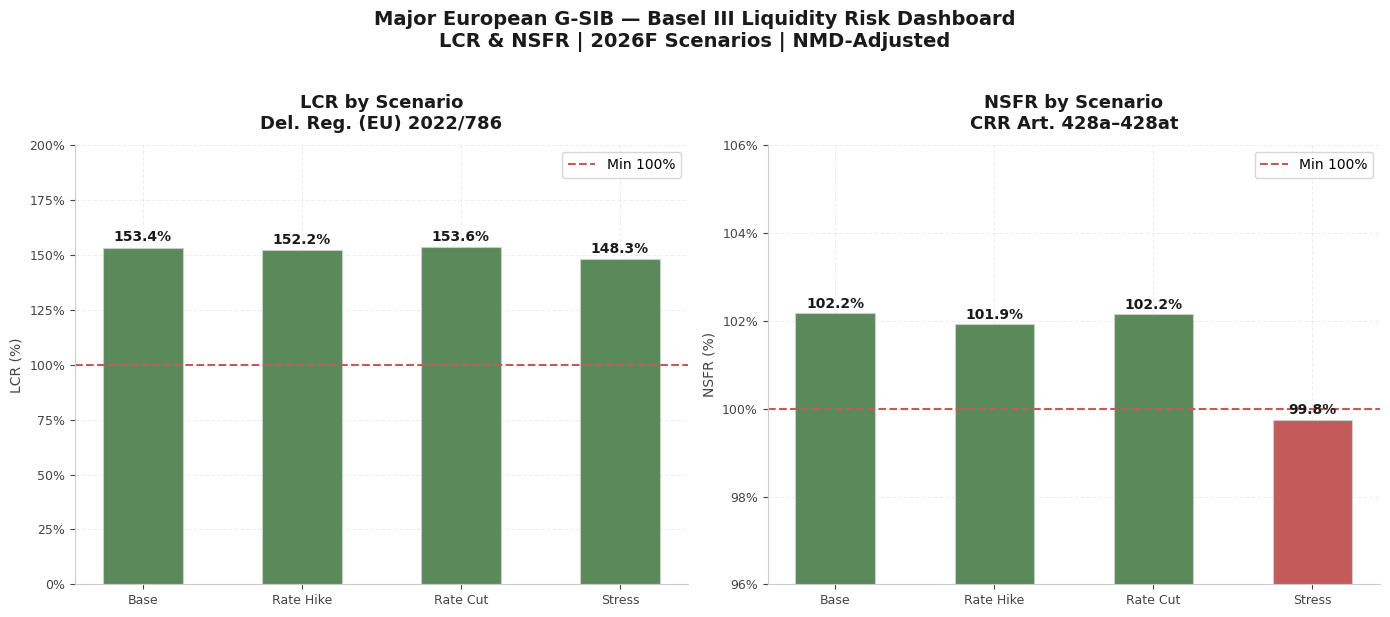

Chart saved ✓

KEY FINDINGS - LIQUIDITY RISK ANALYSIS

LCR - All scenarios pass comfortably (>150%)
  The bank holds a substantial HQLA buffer of 364bn,
  dominated by Level 1 assets (Cash + Govt bonds = 322bn).
  Even under Stress, net outflows are well covered.

NSFR - Stress scenario breaches the 100% minimum (99.8%)
  Under stress, deposit reclassification (NMD model) reduces
  stable deposits from 70% to 50% of the deposit base.
  This compresses ASF by 45bn while RSF remains elevated,
  pushing NSFR below the regulatory floor.

DOMINANT RISK DRIVER
  The insurance asset book (305bn at 100% RSF) is the
  single largest RSF item - it requires 305bn of stable
  funding with no offsetting ASF contribution.

MODEL NOTE
  A static 70/30 deposit split (no NMD model) would show
  a false NSFR pass of 101.4% under Stress. The NMD-adjusted
  model reveals the true regulatory breach, demonstrating
  why behavioural deposit modelling is required under
  EBA/GL/2022/14.



In [8]:
# ── Charts & Findings | LCR and NSFR Scenario Analysis ──────────────────────

scenarios_list = ["Base", "Rate Hike", "Rate Cut", "Stress"]
lcr_vals  = [lcr_df.loc[s, "LCR (%)"]  for s in scenarios_list]
nsfr_vals = [nsfr_df.loc[s, "NSFR (%)"] for s in scenarios_list]

colors_lcr  = ['#5a8a5a' if v >= 100 else '#c45a5a' for v in lcr_vals]
colors_nsfr = ['#5a8a5a' if v >= 100 else '#c45a5a' for v in nsfr_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')
for ax in (ax1, ax2):
    ax.set_facecolor('white')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)

# ── LCR Chart ─────────────────────────────────────────────────────────────────
bars1 = ax1.bar(scenarios_list, lcr_vals, color=colors_lcr,
                width=0.5, edgecolor='#cccccc', linewidth=0.8)
ax1.axhline(100, color='#c45a5a', linewidth=1.5, linestyle='--', label='Min 100%')
ax1.set_title('LCR by Scenario\nDel. Reg. (EU) 2022/786',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax1.set_ylabel('LCR (%)', fontsize=10, color='#444444')
ax1.set_ylim(0, 200)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.legend()

for bar, val in zip(bars1, lcr_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom',
             color='#1a1a1a', fontsize=10, fontweight='bold')

# ── NSFR Chart ────────────────────────────────────────────────────────────────
bars2 = ax2.bar(scenarios_list, nsfr_vals, color=colors_nsfr,
                width=0.5, edgecolor='#cccccc', linewidth=0.8)
ax2.axhline(100, color='#c45a5a', linewidth=1.5, linestyle='--', label='Min 100%')
ax2.set_title('NSFR by Scenario\nCRR Art. 428a–428at',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=12)
ax2.set_ylabel('NSFR (%)', fontsize=10, color='#444444')
ax2.set_ylim(96, 106)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend()

for bar, val in zip(bars2, nsfr_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.1f}%', ha='center', va='bottom',
             color='#1a1a1a', fontsize=10, fontweight='bold')

plt.suptitle('Major European G-SIB — Basel III Liquidity Risk Dashboard\n'
             'LCR & NSFR | 2026F Scenarios | NMD-Adjusted',
             fontsize=14, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.savefig('lcr_nsfr_chart.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Chart saved ✓')

# ── Written Findings ──────────────────────────────────────────────────────────
print('''
KEY FINDINGS - LIQUIDITY RISK ANALYSIS

LCR - All scenarios pass comfortably (>150%)
  The bank holds a substantial HQLA buffer of 364bn,
  dominated by Level 1 assets (Cash + Govt bonds = 322bn).
  Even under Stress, net outflows are well covered.

NSFR - Stress scenario breaches the 100% minimum (99.8%)
  Under stress, deposit reclassification (NMD model) reduces
  stable deposits from 70% to 50% of the deposit base.
  This compresses ASF by 45bn while RSF remains elevated,
  pushing NSFR below the regulatory floor.

DOMINANT RISK DRIVER
  The insurance asset book (305bn at 100% RSF) is the
  single largest RSF item - it requires 305bn of stable
  funding with no offsetting ASF contribution.

MODEL NOTE
  A static 70/30 deposit split (no NMD model) would show
  a false NSFR pass of 101.4% under Stress. The NMD-adjusted
  model reveals the true regulatory breach, demonstrating
  why behavioural deposit modelling is required under
  EBA/GL/2022/14.
''')